In [45]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [5]:
car_data=pd.read_csv('vehicles.csv')
car_data

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
...,...,...,...,...,...,...,...,...,...
296,city,2016,9.50,11.60,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.90,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.00,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.50,9000,Diesel,Dealer,Manual,0


In [6]:
car_data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [7]:
car_data.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [8]:
car_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [9]:
car_data.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [10]:
car_data.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [11]:
print(car_data['Fuel_Type'].value_counts())
print(car_data['Seller_Type'].value_counts())
print(car_data['Transmission'].value_counts())

Petrol    239
Diesel     60
CNG         2
Name: Fuel_Type, dtype: int64
Dealer        195
Individual    106
Name: Seller_Type, dtype: int64
Manual       261
Automatic     40
Name: Transmission, dtype: int64


In [15]:
fuel_type=car_data['Fuel_Type']
seller_type=car_data['Seller_Type']
transmission_type=car_data['Transmission']
selling_price=car_data['Selling_Price']

In [17]:
from matplotlib import style

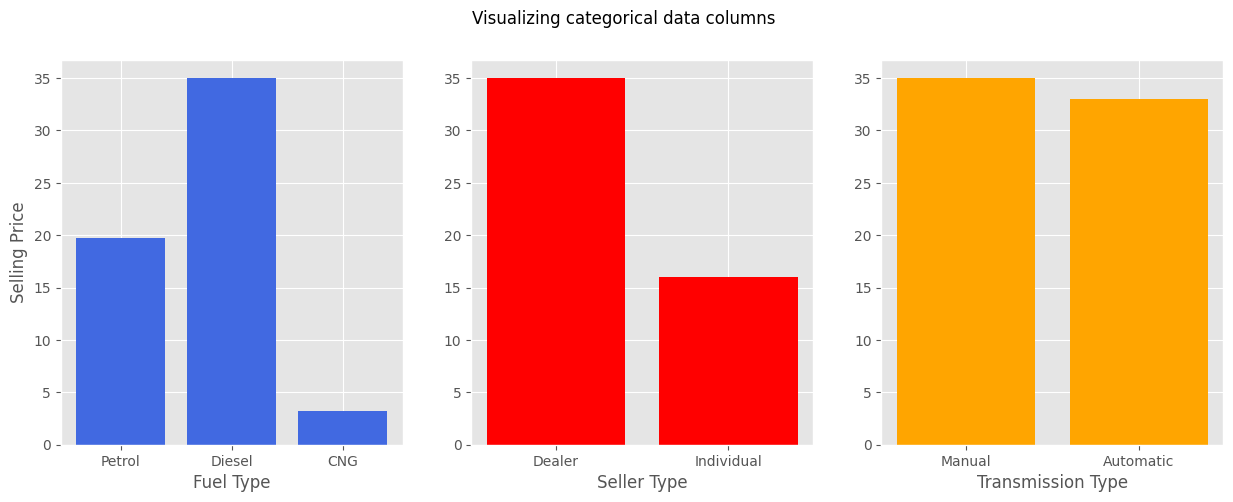

In [18]:
style.use('ggplot')
fig = plt.figure(figsize=(15,5))
fig.suptitle('Visualizing categorical data columns')
plt.subplot(1,3,1)
plt.bar(fuel_type,selling_price,color='royalblue')
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")
plt.subplot(1,3,2)
plt.bar(seller_type,selling_price,color="red")
plt.xlabel("Seller Type")
plt.subplot(1,3,3)
plt.bar(transmission_type,selling_price,color='orange')
plt.xlabel("Transmission Type")
plt.show()

<AxesSubplot: xlabel='Transmission', ylabel='Selling_Price'>

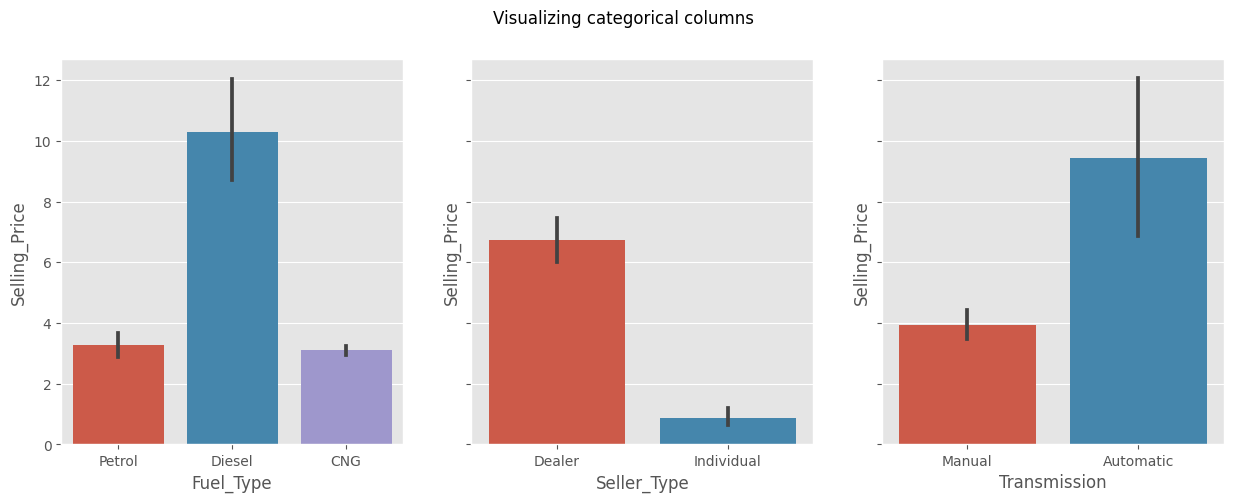

In [20]:
fig, axes = plt.subplots(1,3,figsize=(15,5), sharey=True)
fig.suptitle('Visualizing categorical columns')
sns.barplot(x=fuel_type ,y=selling_price, ax=axes[0])
sns.barplot(x=seller_type ,y=selling_price, ax=axes[1])
sns.barplot(x=transmission_type ,y=selling_price, ax=axes[2])

C:\Users\ELCOT\AppData\Local\Temp\ipykernel_11392\3492936538.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(car_data.corr(), annot=True)


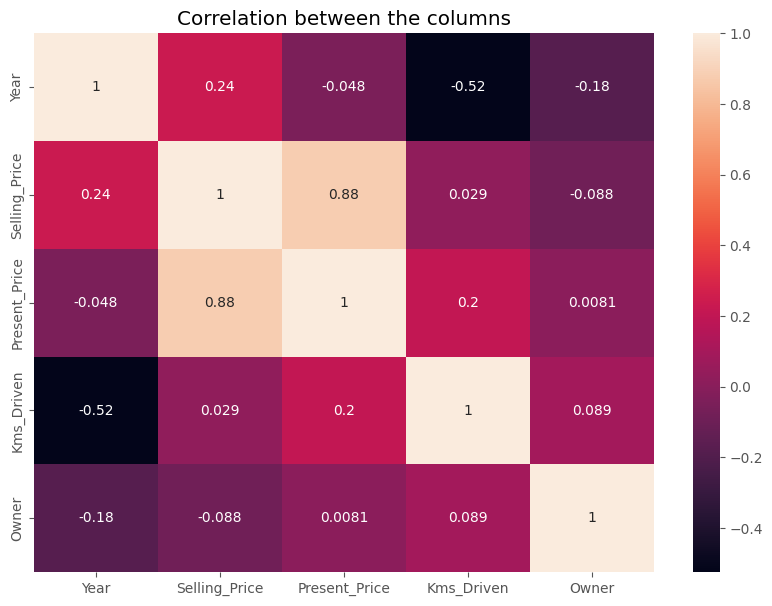

In [21]:
plt.figure(figsize=(10,7))
sns.heatmap(car_data.corr(), annot=True)
plt.title('Correlation between the columns')
plt.show()

<AxesSubplot: title={'center': 'Correlation between present price and selling price'}, xlabel='Present_Price', ylabel='Selling_Price'>

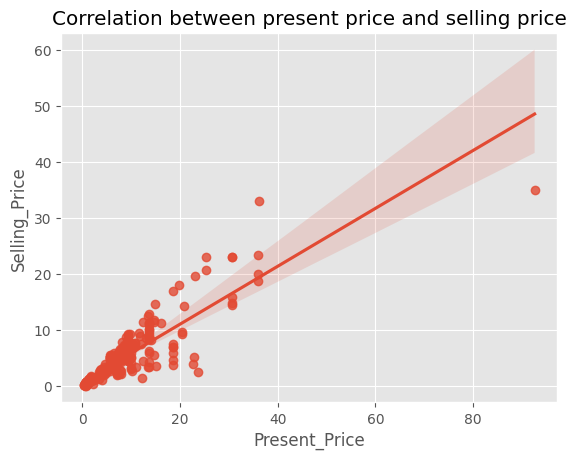

In [24]:
fig=plt.figsize=(7,5)
plt.title("Correlation between present price and selling price")
sns.regplot(x='Present_Price',y='Selling_Price',data=car_data)

In [26]:
x=car_data.drop(['Car_Name','Selling_Price'],axis=1)
y=car_data['Selling_Price']

In [27]:
print("Shape of X is: ",x.shape)
print("Shape of Y is: ",y.shape)

Shape of X is:  (301, 7)
Shape of Y is:  (301,)


In [52]:
x_train,x_test,y_train,y_test=train_test_split(x,y, test_size=0.2, random_state=42)
print(x_train.dtypes)

Year               int64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object


In [30]:
print("Shape of X_train is: ",x_train.shape)
print("Shape of X_test is: ",x_test.shape)
print("Shape of Y_train is: ",y_train.shape)
print("Shape of Y_test is: ",y_test.shape)

Shape of X_train is:  (240, 7)
Shape of X_test is:  (61, 7)
Shape of Y_train is:  (240,)
Shape of Y_test is:  (61,)


In [53]:
x_train = pd.get_dummies(x_train,drop_first=True)
x_test = pd.get_dummies(x_test,drop_first=True)
x_train,x_test= x_train.align(x_test,join='left',axis=1,fill_value=0)

In [54]:
scaler=StandardScaler()
X_train=scaler.fit_transform(x_train)
X_test=scaler.transform(x_test)

In [55]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [56]:
pred=model.predict(X_test)
print("Intercept:",model.intercept_)
print("Coefficient:",model.coef_)

Intercept: 4.642291666666672
Coefficient: [ 1.01852295  3.85078399 -0.25715831 -0.24334478  0.98876764  0.29305275
 -0.57090209 -0.54205543]


In [57]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

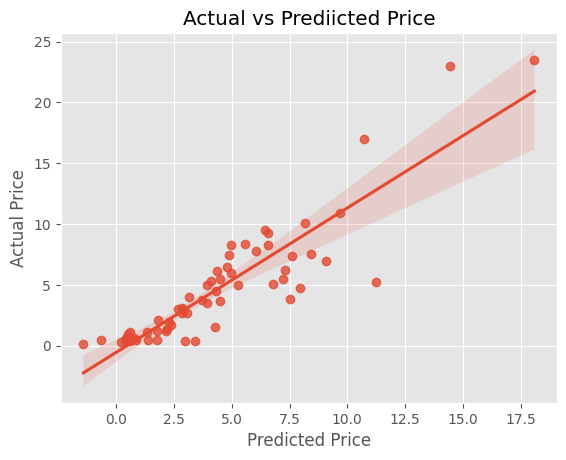

In [58]:
sns.regplot(x=pred , y=y_test)
plt.xlabel("Predicted Price")
plt.ylabel("Actual Price")
plt.title("Actual vs Prediicted Price")
plt.show()

In [59]:
print("Mean Absolute Error:" ,(metrics.mean_absolute_error(pred,y_test)))
print("Mean Squared Error:" ,(metrics.mean_squared_error(pred,y_test)))
print("R2 score:" ,(metrics.r2_score(pred,y_test)))

Mean Absolute Error: 1.5168426908503998
Mean Squared Error: 5.1148414072202995
R2 score: 0.6100893172810194


In [60]:
df=pd.DataFrame({'ACTUAL':y_test,'PREDICTED':pred.flatten()})

In [61]:
df

,ACTUAL,PREDICTED
177,0.35,2.955343
289,10.11,8.178939
228,4.95,3.921000
198,0.15,-1.424175
60,6.95,9.088899
...,...,...
234,5.50,4.474781
296,9.50,6.440504
281,2.10,1.822946
285,7.40,7.604167
